## Preparation

In [1]:
import os
import anndata
import scanpy as sc
import random
import torch
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import sys
import os

from pathlib import Path
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import silhouette_score as s_score

stClinic_root = r'E:\yan0\multi-sample-disentangle\baseline\stClinic-main\stClinic-main'
if os.path.exists(stClinic_root) and stClinic_root not in sys.path:
    sys.path.insert(0, stClinic_root)

import stClinic as stClinic

warnings.filterwarnings("ignore")

d:\anaconda3\envs\my\Lib\site-packages\anndata\utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
d:\anaconda3\envs\my\Lib\site-packages\anndata\utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
d:\anaconda3\envs\my\Lib\site-packages\anndata\utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
d:\anaconda3\envs\my\Lib\site-packages\anndata\utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
d:\anaconda3\envs\my\Lib\site-packages\anndata\utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
d:\anacon

In [2]:
used_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(used_device)

cuda:0


In [3]:
# Set seed
seed    = 666
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

## Load Data

In [4]:
# ============================================================================
# Read CODEX CSV and Convert to AnnData (with coordinates)
# ============================================================================

import pandas as pd
import numpy as np
from anndata import AnnData
import scanpy as sc

# 文件路径
file_path = r'E:/yan0/multi-sample-disentangle/multi-sample-data/CODEX/CRC_clusters_neighborhoods_markers.csv'

print("Reading CSV file...")
df = pd.read_csv(file_path, low_memory=False)
print(f"  Loaded {len(df)} cells/spots")
print(f"  Total columns: {len(df.columns)}")

# 坐标列（主要坐标）
coord_cols = ['X:X', 'Y:Y']
if 'Z:Z' in df.columns:
    coord_cols.append('Z:Z')

# 细胞类型注释列
cell_type_cols = ['ClusterID', 'ClusterName']
if 'ClusterID' not in df.columns:
    cell_type_cols = [col for col in df.columns if 'cluster' in col.lower()]

# 邻域列
neighborhood_cols = ['neighborhood10', 'neighborhood number final', 'neighborhood name']

# 表达谱列（所有marker，以 'Cyc_' 开头的列）
expression_cols = []
for col in df.columns:
    if ':Cyc_' in col or 'Cyc_' in col:
        # 检查是否为数值列
        if df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
            expression_cols.append(col)

# 如果没找到，尝试其他方式识别marker列
if len(expression_cols) == 0:
    # 查找包含marker名称的列（如 CD44, FOXP3 等）
    marker_keywords = ['CD', 'FOXP3', 'p53', 'GATA3', 'HLA-DR', 'PD-L1', 'Ki67', 
                      'MUC-1', 'Vimentin', 'Cytokeratin', 'EGFR', 'CDX2']
    for col in df.columns:
        if any(keyword in col for keyword in marker_keywords):
            if df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
                if col not in coord_cols:
                    expression_cols.append(col)

print(f"\nDetected columns:")
print(f"  Coordinates: {coord_cols}")
print(f"  Cell types: {cell_type_cols}")
print(f"  Neighborhoods: {neighborhood_cols}")
print(f"  Expression markers: {len(expression_cols)} markers")

# 创建AnnData对象
# 表达矩阵
if len(expression_cols) > 0:
    X = df[expression_cols].values.astype(np.float32)
    var_names = expression_cols
else:
    raise ValueError("No expression columns found!")

# 创建AnnData
adata = AnnData(X)
adata.var_names = var_names
adata.obs_names = df['CellID'].values if 'CellID' in df.columns else [f"cell_{i}" for i in range(len(df))]

# 添加坐标信息到 obsm['spatial']
if 'X:X' in df.columns and 'Y:Y' in df.columns:
    spatial_coords = df[['X:X', 'Y:Y']].values.astype(np.float32)
    adata.obsm['spatial'] = spatial_coords
    print(f"\n  ✓ Added spatial coordinates (X, Y) to adata.obsm['spatial']")
    
    # 如果有Z坐标，也添加
    if 'Z:Z' in df.columns:
        adata.obsm['spatial_3d'] = df[['X:X', 'Y:Y', 'Z:Z']].values.astype(np.float32)
        print(f"  ✓ Added 3D coordinates (X, Y, Z) to adata.obsm['spatial_3d']")
    
    # 瓦片内坐标（可选）
    if 'X_withinTile:X_withinTile' in df.columns and 'Y_withinTile:Y_withinTile' in df.columns:
        adata.obsm['spatial_within_tile'] = df[['X_withinTile:X_withinTile', 'Y_withinTile:Y_withinTile']].values.astype(np.float32)
        print(f"  ✓ Added within-tile coordinates to adata.obsm['spatial_within_tile']")

# 添加细胞类型注释到obs
for col in cell_type_cols:
    if col in df.columns:
        adata.obs[col] = df[col].values
        print(f"  ✓ Added {col} to adata.obs")

# 添加邻域信息到obs
for col in neighborhood_cols:
    if col in df.columns:
        adata.obs[col] = df[col].values
        print(f"  ✓ Added {col} to adata.obs")

# 添加其他重要元数据到obs
metadata_cols = ['EventID', 'File Name', 'Region', 'TMA_AB', 'TMA_12', 
                 'groups', 'patients', 'spots', 'ClusterSize']
for col in metadata_cols:
    if col in df.columns:
        adata.obs[col] = df[col].values
        print(f"  ✓ Added {col} to adata.obs")

# 添加组合marker列（如 CD4+ICOS+ 等）到obs（如果存在）
combo_markers = [col for col in df.columns if '+' in col and col not in expression_cols]
for col in combo_markers[:10]:  # 只添加前10个
    if col in df.columns:
        adata.obs[col] = df[col].values

print(f"\n✓ AnnData created successfully!")
print(f"  Shape: {adata.shape}")
print(f"  Observations (cells): {adata.n_obs}")
print(f"  Variables (markers): {adata.n_vars}")
print(f"\n  adata.obs columns ({len(adata.obs.columns)}): {list(adata.obs.columns)}")
print(f"  adata.obsm keys: {list(adata.obsm.keys())}")

# 显示前几行数据预览
print(f"\nFirst few rows of adata.obs:")
print(adata.obs[['ClusterID', 'ClusterName', 'neighborhood name']].head() if 'ClusterName' in adata.obs.columns else adata.obs.head())

# 显示表达矩阵统计
print(f"\nExpression matrix statistics:")
print(f"  Min: {X.min():.2f}, Max: {X.max():.2f}, Mean: {X.mean():.2f}, Std: {X.std():.2f}")

# 显示坐标范围
if 'spatial' in adata.obsm:
    coords = adata.obsm['spatial']
    print(f"\nSpatial coordinates range:")
    print(f"  X: [{coords[:, 0].min():.2f}, {coords[:, 0].max():.2f}]")
    print(f"  Y: [{coords[:, 1].min():.2f}, {coords[:, 1].max():.2f}]")

Reading CSV file...
  Loaded 258385 cells/spots
  Total columns: 99

Detected columns:
  Coordinates: ['X:X', 'Y:Y', 'Z:Z']
  Cell types: ['ClusterID', 'ClusterName']
  Neighborhoods: ['neighborhood10', 'neighborhood number final', 'neighborhood name']
  Expression markers: 58 markers

  ✓ Added spatial coordinates (X, Y) to adata.obsm['spatial']
  ✓ Added 3D coordinates (X, Y, Z) to adata.obsm['spatial_3d']
  ✓ Added within-tile coordinates to adata.obsm['spatial_within_tile']
  ✓ Added ClusterID to adata.obs
  ✓ Added ClusterName to adata.obs
  ✓ Added neighborhood10 to adata.obs
  ✓ Added neighborhood number final to adata.obs
  ✓ Added neighborhood name to adata.obs
  ✓ Added EventID to adata.obs
  ✓ Added File Name to adata.obs
  ✓ Added Region to adata.obs
  ✓ Added TMA_AB to adata.obs
  ✓ Added TMA_12 to adata.obs
  ✓ Added groups to adata.obs
  ✓ Added patients to adata.obs
  ✓ Added spots to adata.obs
  ✓ Added ClusterSize to adata.obs

✓ AnnData created successfully!
  Shape:

In [5]:
Batch_list  = []
adj_list    = []

------Calculating intra-spatial graph...
The graph contains 33358 edges, 3726 cells.
8.9528 neighbors per spot on average.


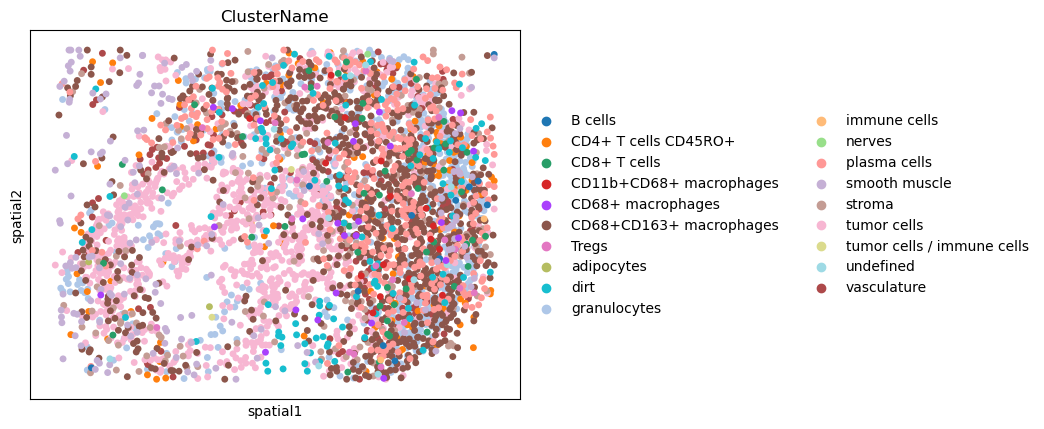

In [7]:
adata1 = adata[adata.obs['patients']==4]
adata2 = adata1[adata1.obsm['spatial_3d'][:,2]==8]
adata2
sc.pl.spatial(adata2, img_key="hires", color=["ClusterName"], spot_size=30, show=False)
sc.pp.filter_genes(adata2, min_cells=50)

# Normalization
sc.pp.highly_variable_genes(adata2, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata2, target_sum=1e4)
sc.pp.log1p(adata2)

adata2 = adata2[:, adata2.var['highly_variable']]
adata2.obs['Ground Truth'] = adata2.obs['ClusterName'].astype('category')

# Constructing the spatial network
stClinic.Cal_Spatial_Net(adata2, rad_cutoff=40) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

------Calculating intra-spatial graph...
The graph contains 20682 edges, 2993 cells.
6.9101 neighbors per spot on average.


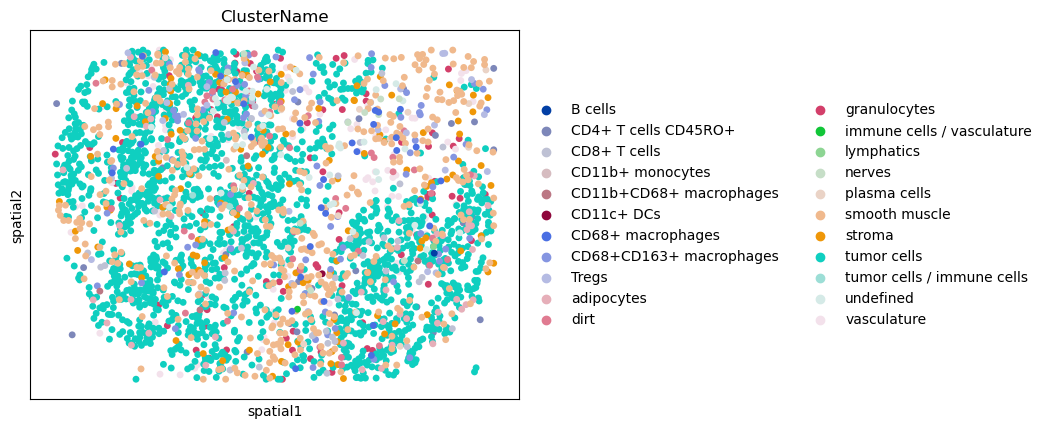

In [8]:
adata1 = adata[adata.obs['patients']==21]
# adata1
adata2 = adata1[adata1.obsm['spatial_3d'][:,2]==7]
sc.pl.spatial(adata2, img_key="hires", color=["ClusterName"], spot_size=30, show=False)
sc.pp.filter_genes(adata2, min_cells=50)

# Normalization
sc.pp.highly_variable_genes(adata2, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata2, target_sum=1e4)
sc.pp.log1p(adata2)

adata2 = adata2[:, adata2.var['highly_variable']]
adata2.obs['Ground Truth'] = adata2.obs['ClusterName'].astype('category')

# Constructing the spatial network
stClinic.Cal_Spatial_Net(adata2, rad_cutoff=40) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

------Calculating intra-spatial graph...
The graph contains 15046 edges, 2490 cells.
6.0426 neighbors per spot on average.


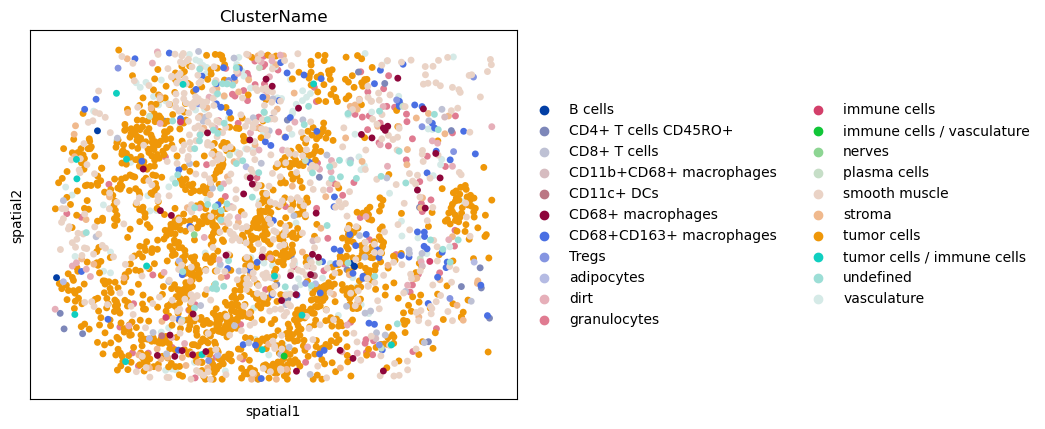

In [9]:
adata1 = adata[adata.obs['patients']==21]
# adata1
adata2 = adata1[adata1.obsm['spatial_3d'][:,2]==8]
sc.pl.spatial(adata2, img_key="hires", color=["ClusterName"], spot_size=30, show=False)
sc.pp.filter_genes(adata2, min_cells=50)

# Normalization
sc.pp.highly_variable_genes(adata2, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata2, target_sum=1e4)
sc.pp.log1p(adata2)

adata2 = adata2[:, adata2.var['highly_variable']]
adata2.obs['Ground Truth'] = adata2.obs['ClusterName'].astype('category')

# Constructing the spatial network
stClinic.Cal_Spatial_Net(adata2, rad_cutoff=40) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

In [10]:
section_ids = [str(i+1) for i in range(len(Batch_list))]

In [11]:
# Concat scanpy objects
adata_concat = anndata.concat(Batch_list, label="slice_name", keys=section_ids)
adata_concat.obs['Ground Truth'] = adata_concat.obs['Ground Truth'].astype('category')
adata_concat.obs["batch_name"]   = adata_concat.obs["slice_name"].astype('category')
print('\nShape of concatenated AnnData object: ', adata_concat.shape)

# Construct unified graph
# mnn_dict = create_dictionary_mnn(adata_concat, use_rep='X_pca', batch_name='batch_name', k=1) # k=0
adj_concat = stClinic.inter_linked_graph(adj_list, section_ids, mnn_dict=None)
adata_concat.uns['adj']      = adj_concat
adata_concat.uns['edgeList'] = np.nonzero(adj_concat)


Shape of concatenated AnnData object:  (9209, 58)


In [12]:
# Run stClinic for unsupervised integration
centroids_num = 6
print(f'Estimated centroids number: {centroids_num}')
adata_concat  = stClinic.train_stClinic_model(adata_concat, n_centroids=centroids_num, lr=0.0005, device=used_device)

# Clustering
stClinic.mclust_R(adata_concat, num_cluster=len(np.unique(adata_concat.obs[adata_concat.obs['Ground Truth']!='unknown']['Ground Truth'])), used_obsm='stClinic')
adata_concat = adata_concat[adata_concat.obs['Ground Truth']!='unknown']

Batch_list1   = []
for section_id in section_ids:
	Batch_list1.append(adata_concat[adata_concat.obs['batch_name'] == section_id])

Estimated centroids number: 6
Pretrain with unregularized stClinic (without GMM regularizer)...


Epochs:   0%|          | 0/300 [00:00<?, ?it/s]

Initialize Gaussian Mixture Model...
Selected initial type: GMM
Train with regularized stClinic (with GMM regularizer)...


Epochs:   0%|          | 0/400 [00:00<?, ?it/s]

Prune edges...
Prune edges...


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [13]:
adata_concat

View of AnnData object with n_obs × n_vars = 9209 × 58
    obs: 'ClusterID', 'ClusterName', 'neighborhood10', 'neighborhood number final', 'neighborhood name', 'EventID', 'File Name', 'Region', 'TMA_AB', 'TMA_12', 'groups', 'patients', 'spots', 'ClusterSize', 'CD4+ICOS+', 'CD4+Ki67+', 'CD4+PD-1+', 'CD68+CD163+ICOS+', 'CD68+CD163+Ki67+', 'CD68+CD163+PD-1+', 'CD68+ICOS+', 'CD68+Ki67+', 'CD68+PD-1+', 'CD8+ICOS+', 'Ground Truth', 'slice_name', 'batch_name', 'GMM_cluster', 'mclust'
    uns: 'adj', 'edgeList'
    obsm: 'spatial', 'spatial_3d', 'spatial_within_tile', 'stClinic'

## Clustering

In [16]:
stClinic.mclust_R(adata_concat, num_cluster=6, used_obsm='stClinic')
adata_concat = adata_concat[adata_concat.obs['Ground Truth']!='unknown']

from sklearn.metrics import adjusted_rand_score as ari_score
print('mclust, ARI = %01.3f' % ari_score(adata_concat.obs['Ground Truth'], adata_concat.obs['mclust']))

fitting ...
  |======================================================================| 100%
mclust, ARI = 0.140


## Visualization

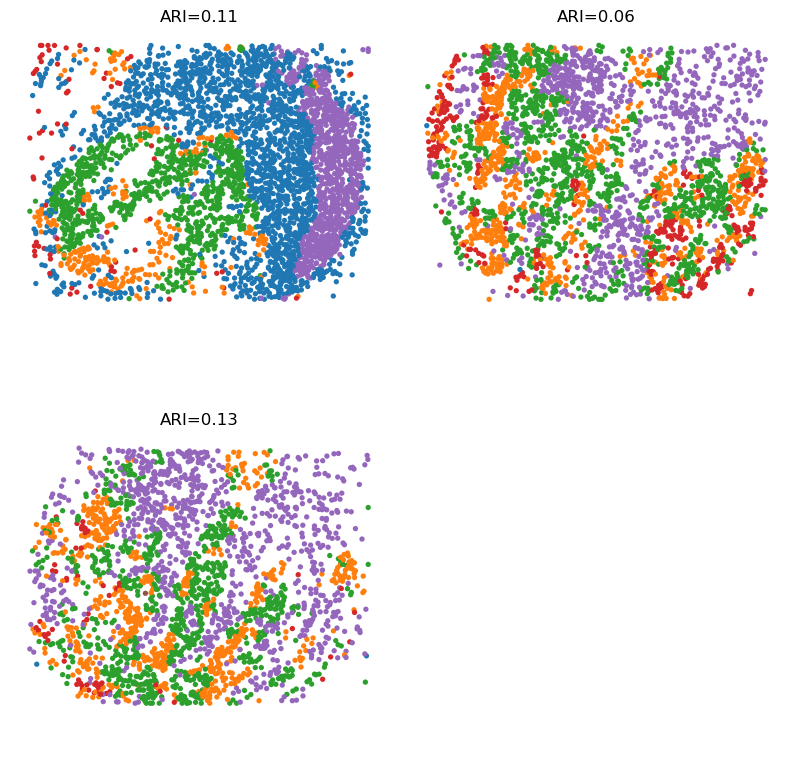

In [17]:
Batch_list1 = []
for section_id in section_ids:
    Batch_list1.append(adata_concat[adata_concat.obs['batch_name'] == section_id])
from sklearn.metrics import adjusted_rand_score as ari_score
import math

import matplotlib.pyplot as plt
spot_size = 30
title_size = 12

# 根据实际数量计算ARI
n_batches = len(Batch_list1)
ARI_list = []
for bb in range(n_batches):
    ARI_list.append(round(ari_score(Batch_list1[bb].obs['Ground Truth'], Batch_list1[bb].obs['mclust']), 2))

# 计算子图布局：固定2列，行数根据数量计算
n_cols = 2
n_rows = math.ceil(n_batches / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})

# 确保axes是二维数组
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# 绘制每个batch
for bb in range(n_batches):
    row = bb // n_cols
    col = bb % n_cols
    ax = axes[row, col]
    
    _sc = sc.pl.spatial(Batch_list1[bb], img_key=None, color=['mclust'], title=[''],
                        legend_loc=None, legend_fontsize=12, show=False, ax=ax, frameon=False,
                        spot_size=spot_size)
    _sc[0].set_title("ARI=" + str(ARI_list[bb]), size=title_size)

# 隐藏多余的子图
for bb in range(n_batches, n_rows * n_cols):
    row = bb // n_cols
    col = bb % n_cols
    axes[row, col].axis('off')

In [ ]:
# UMAP reduction
sc.pp.neighbors(adata_concat, use_rep='stClinic', random_state=seed)
sc.tl.umap(adata_concat, random_state=seed)

Text(0.5, 1.0, 'ARI=0.2')

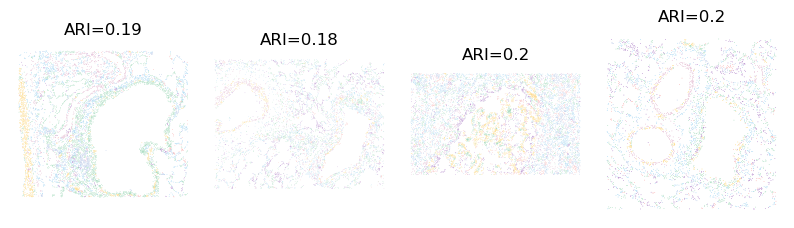

In [20]:

spot_size  = 6
title_size = 12
ARI_list   = []
for bb in range(4):
	ARI_list.append(round(ari_score(Batch_list1[bb].obs['Ground Truth'], Batch_list1[bb].obs['mclust']), 2))

colors  = ["#6D1A9B", "#CB79A6", "#7494D2", "#59BD85", "#56B3E8", "#FDB815", "#F46867"]
fig, ax = plt.subplots(1, 4, figsize=(10, 5), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})

_sc_0 = sc.pl.spatial(Batch_list1[0], img_key=None, color=['mclust'], title=[''],spot_size=spot_size, legend_loc=None, 
					  legend_fontsize=12, show=False, ax=ax[0], frameon=False, palette=colors)
_sc_0[0].set_title("ARI=" + str(ARI_list[0]), size=12)
_sc_1 = sc.pl.spatial(Batch_list1[1], img_key=None, color=['mclust'], title=[''],spot_size=spot_size, legend_loc=None,
					  legend_fontsize=12, show=False, ax=ax[1], frameon=False, palette=colors)
_sc_1[0].set_title("ARI=" + str(ARI_list[1]), size=12)
_sc_2 = sc.pl.spatial(Batch_list1[2], img_key=None, color=['mclust'], title=[''],spot_size=spot_size, legend_loc=None,
					  legend_fontsize=12, show=False, ax=ax[2], frameon=False, palette=colors)
_sc_2[0].set_title("ARI=" + str(ARI_list[2]), size=12)
_sc_3 = sc.pl.spatial(Batch_list1[3], img_key=None, color=['mclust'], title=[''],spot_size=spot_size, legend_loc=None,
					  legend_fontsize=12, show=False, ax=ax[3], frameon=False, palette=colors)
_sc_3[0].set_title("ARI=" + str(ARI_list[3]), size=12)

Text(0.5, 1.0, 'ARI=0.4')

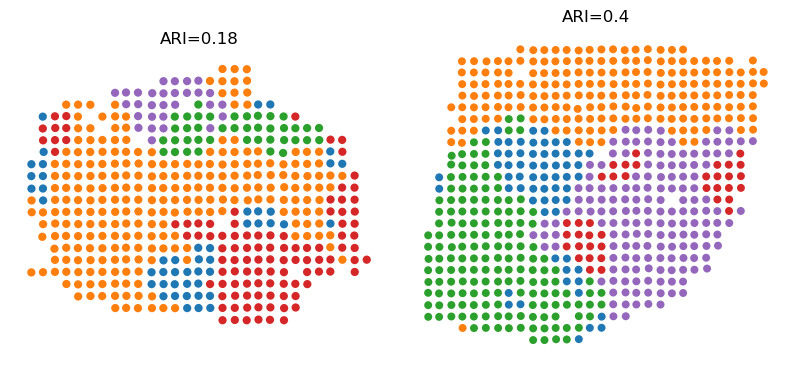

In [33]:
Batch_list = []
for section_id in section_ids:
    Batch_list.append(adata_concat[adata_concat.obs['batch_name'] == section_id])

import matplotlib.pyplot as plt
spot_size = 200
title_size = 12
ARI_list = []
for bb in range(2):
    ARI_list.append(round(ari_score(Batch_list[bb].obs['Ground Truth'], Batch_list[bb].obs['mclust']), 2))

fig, ax = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})
_sc_0 = sc.pl.spatial(Batch_list[0], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[0], frameon=False,
                      spot_size=spot_size)
_sc_0[0].set_title("ARI=" + str(ARI_list[0]), size=title_size)
_sc_1 = sc.pl.spatial(Batch_list[1], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[1], frameon=False,
                      spot_size=spot_size)
_sc_1[0].set_title("ARI=" + str(ARI_list[1]), size=title_size)
